In [6]:

from scipy.stats.stats import pearsonr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy import stats
import sklearn 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D 


/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_33193/1475174876.py:1: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


In [39]:
import pandas as pd

def preview_and_count_csv(path, preview_rows=10000):
    total_rows = 0
    preview_df = None

    for i, chunk in enumerate(pd.read_csv(path, chunksize=preview_rows)):
        total_rows += len(chunk)
        if i == 0:
            preview_df = chunk.copy()
        break
    return total_rows, preview_df

total_rows, first_1000 = preview_and_count_csv("medicaid-provider-spending.csv")
print("Total rows:", total_rows)
first_1000

Total rows: 10000


,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID
0,1376609297,1376609297,T1019,2024-07,39765,1205701,1.188877e+08
1,1376609297,1376609297,T1019,2024-08,39677,1152534,1.155611e+08
2,1376609297,1376609297,T1019,2024-05,39678,1157235,1.128233e+08
3,1376609297,1376609297,T1019,2024-06,39834,1164582,1.114492e+08
4,1376609297,1376609297,T1019,2024-09,39527,1099808,1.111998e+08
...,...,...,...,...,...,...,...
9995,1295869428,1295869428,T2016,2020-09,328,397,3.984698e+06
9996,1770700221,1770700221,99199,2022-05,737,737,3.984687e+06
9997,1730278409,1730278409,T1019,2020-09,1125,27129,3.984595e+06
9998,1295869428,1295869428,T2016,2021-04,329,421,3.984424e+06


In [20]:
import duckdb
import matplotlib.pyplot as plt
csv_path = "medicaid-provider-spending.csv"

# 1) Open an in-memory DuckDB database
con = duckdb.connect()


In [ ]:

# 3) Get top 50 codes with frequencies
top50_df = con.execute(f"""
    SELECT
        HCPCS_CODE,
        COUNT(*) AS freq
    FROM read_csv_auto('{csv_path}')
    GROUP BY HCPCS_CODE
    ORDER BY freq DESC
    LIMIT 50
""").fetchdf()

Number of distinct HCPCS_CODE values: 10881


In [37]:
top50_df

,HCPCS_CODE,freq
0,99213,13566914
1,99214,11728025
2,99284,3980198
3,99283,3270001
4,99285,2901462
5,36415,2730219
6,T1015,2429393
7,D0120,2280791
8,85025,2259404
9,90837,1869501


In [9]:

# Sample up to 100,000 rows for plotting
claims_paid_df = con.execute(f"""
    SELECT
        CAST(TOTAL_CLAIMS AS DOUBLE) AS TOTAL_CLAIMS,
        CAST(TOTAL_PAID   AS DOUBLE) AS TOTAL_PAID
    FROM read_csv_auto('{csv_path}')
    USING SAMPLE 100000 ROWS
""").fetchdf()

In [10]:
benef_df = con.execute(f"""
    SELECT CAST(TOTAL_UNIQUE_BENEFICIARIES AS DOUBLE) AS TOTAL_UNIQUE_BENEFICIARIES
    FROM read_csv_auto('{csv_path}')
""").fetchdf()

In [11]:
# 6. Relationship between TOTAL_UNIQUE_BENEFICIARIES and TOTAL_CLAIMS (scatter, log-log)


benef_claims_df = con.execute(f"""
    SELECT
        CAST(TOTAL_UNIQUE_BENEFICIARIES AS DOUBLE) AS TOTAL_UNIQUE_BENEFICIARIES,
        CAST(TOTAL_CLAIMS                AS DOUBLE) AS TOTAL_CLAIMS
    FROM read_csv_auto('{csv_path}')
    USING SAMPLE 100000 ROWS
""").fetchdf()


In [21]:

claims_per_benef_df = con.execute(f"""
    SELECT
        CAST(TOTAL_CLAIMS AS DOUBLE) /
        NULLIF(CAST(TOTAL_UNIQUE_BENEFICIARIES AS DOUBLE), 0) AS claims_per_beneficiary
    FROM read_csv_auto('{csv_path}')
    USING SAMPLE 100000 ROWS
""").fetchdf()

# Drop any rows where the ratio is NULL (e.g., zero beneficiaries)
claims_per_benef = claims_per_benef_df["claims_per_beneficiary"].dropna()

In [26]:

monthly_paid_df = con.execute(f"""
    SELECT
        CLAIM_FROM_MONTH,
        SUM(CAST(TOTAL_PAID AS DOUBLE)) AS total_paid
    FROM read_csv_auto('{csv_path}')
    GROUP BY CLAIM_FROM_MONTH
    ORDER BY CLAIM_FROM_MONTH
""").fetchdf()

# If CLAIM_FROM_MONTH is like '2024-07', parse to datetime for nicer plotting
monthly_paid_df["CLAIM_FROM_MONTH"] = pd.to_datetime(monthly_paid_df["CLAIM_FROM_MONTH"])
monthly_paid_df = monthly_paid_df.sort_values("CLAIM_FROM_MONTH")

In [28]:
top3_codes = (
    top50_df.sort_values("freq", ascending=False)
            .head(3)["HCPCS_CODE"]
            .tolist()
)
codes_tuple = tuple(top3_codes)  # e.g. ('T1019', 'T2016', '99199')

monthly_code_paid_df = con.execute(f"""
    SELECT
        HCPCS_CODE,
        CLAIM_FROM_MONTH,
        SUM(CAST(TOTAL_PAID AS DOUBLE)) AS total_paid
        -- If you want monthly claim counts instead, use: COUNT(*) AS total_claims
    FROM read_csv_auto('{csv_path}')
    WHERE HCPCS_CODE IN {codes_tuple}
    GROUP BY HCPCS_CODE, CLAIM_FROM_MONTH
    ORDER BY HCPCS_CODE, CLAIM_FROM_MONTH
""").fetchdf()

In [30]:

hcpcs_spend_df = con.execute(f"""
    SELECT
        HCPCS_CODE,
        SUM(CAST(TOTAL_PAID AS DOUBLE)) AS total_paid
    FROM read_csv_auto('{csv_path}')
    GROUP BY HCPCS_CODE
    ORDER BY total_paid DESC
    LIMIT 20
""").fetchdf()

# Optional: compute share of total spend for these top 20 codes
total_spend = hcpcs_spend_df["total_paid"].sum()
hcpcs_spend_df["share_of_spend"] = hcpcs_spend_df["total_paid"] / total_spend

In [32]:

provider_spend_df = con.execute(f"""
    SELECT
        BILLING_PROVIDER_NPI_NUM,
        SUM(CAST(TOTAL_PAID AS DOUBLE)) AS total_paid
    FROM read_csv_auto('{csv_path}')
    GROUP BY BILLING_PROVIDER_NPI_NUM
    ORDER BY total_paid DESC
    LIMIT 20
""").fetchdf()

# Optional: share of spend among these top 20
total_spend_providers = provider_spend_df["total_paid"].sum()
provider_spend_df["share_of_spend"] = provider_spend_df["total_paid"] / total_spend_providers

In [34]:

billing_serving_match_df = con.execute(f"""
    SELECT
        CASE
            WHEN BILLING_PROVIDER_NPI_NUM = SERVICING_PROVIDER_NPI_NUM
                THEN 'same'
            ELSE 'different'
        END AS same_vs_different,
        COUNT(*) AS cnt
    FROM read_csv_auto('{csv_path}')
    GROUP BY same_vs_different
""").fetchdf()

# Compute percentages
total_cnt = billing_serving_match_df["cnt"].sum()
billing_serving_match_df["percent"] = billing_serving_match_df["cnt"] / total_cnt * 100.0

# PLOTS

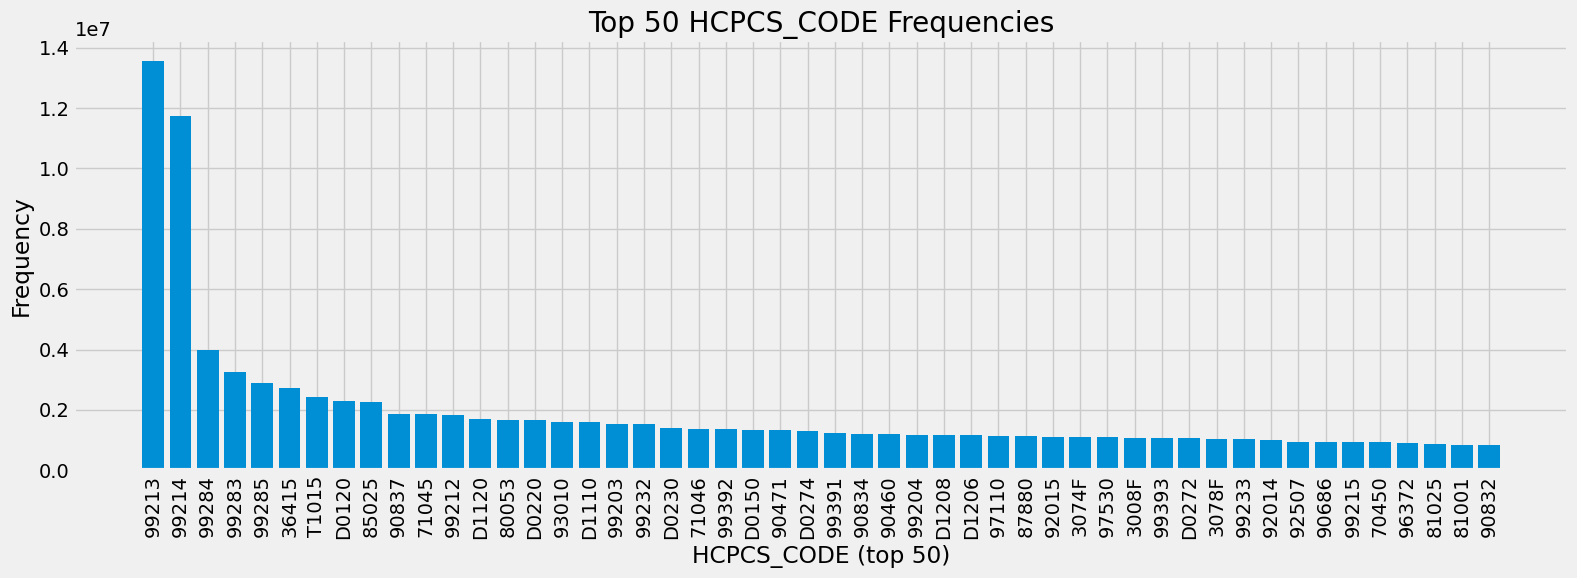

In [ ]:


# 4) Plot histogram (bar plot) for top 50
plt.figure(figsize=(16, 6))
plt.bar(top50_df["HCPCS_CODE"].astype(str), top50_df["freq"])
plt.xticks(rotation=90)
plt.xlabel("HCPCS_CODE (top 50)")
plt.ylabel("Frequency")
plt.title("Top 50 HCPCS_CODE Frequencies")
plt.tight_layout()
plt.show()

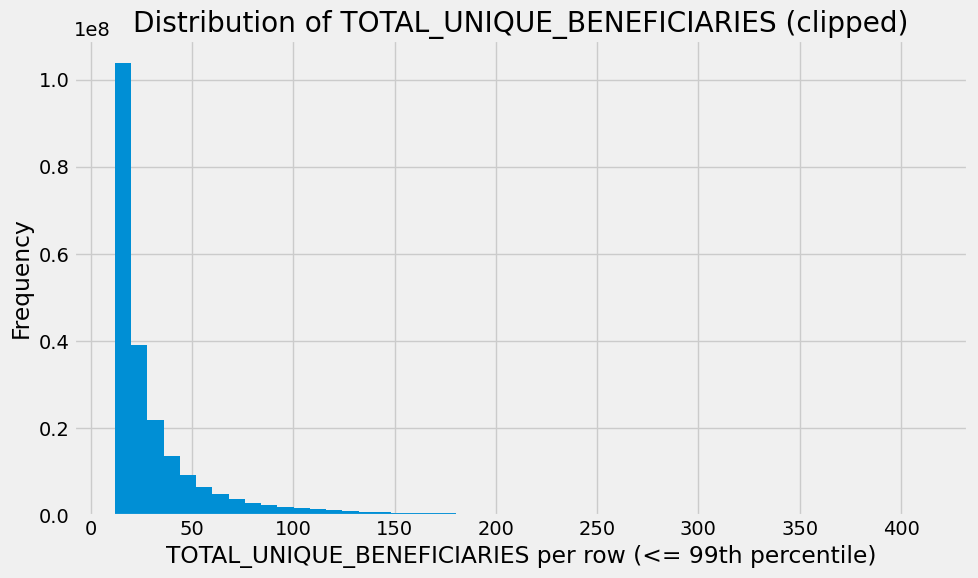

In [13]:
# Optional: clipped version if very skewed



vals_benef = benef_df["TOTAL_UNIQUE_BENEFICIARIES"]
upper_benef = vals_benef.quantile(0.99)
plt.figure(figsize=(10, 6))
plt.hist(vals_benef[vals_benef <= upper_benef], bins=50)
plt.xlabel("TOTAL_UNIQUE_BENEFICIARIES per row (<= 99th percentile)")
plt.ylabel("Frequency")
plt.title("Distribution of TOTAL_UNIQUE_BENEFICIARIES (clipped)")
plt.tight_layout()
plt.show()

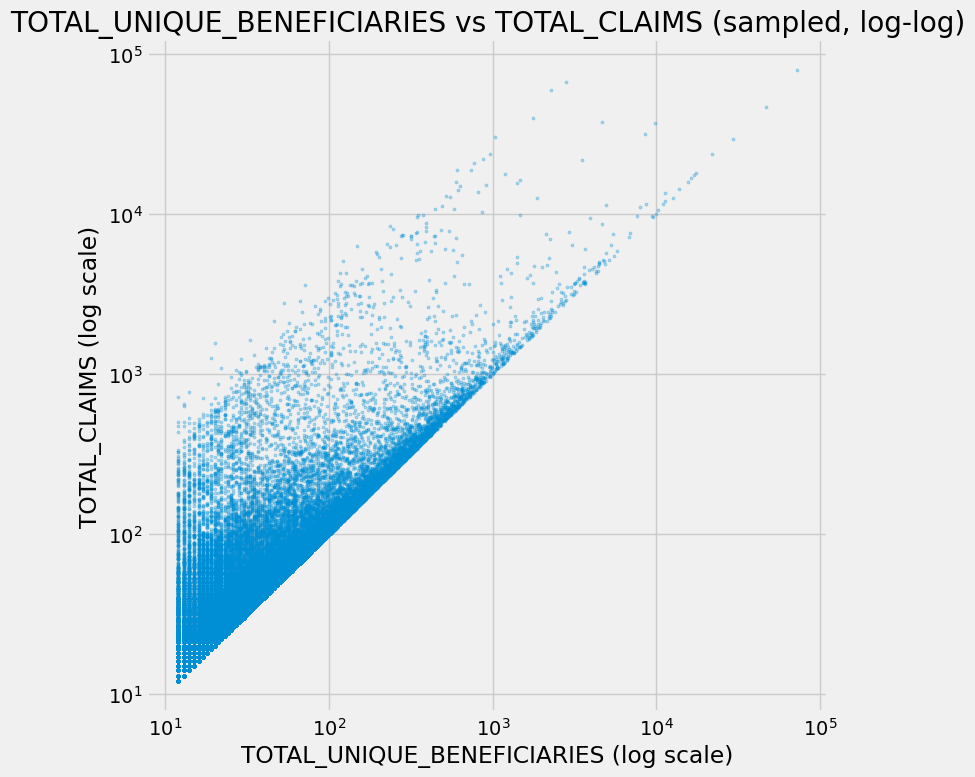

In [14]:

# Filter out non-positive values before log scales
mask = (benef_claims_df["TOTAL_UNIQUE_BENEFICIARIES"] > 0) & (benef_claims_df["TOTAL_CLAIMS"] > 0)
plot_df = benef_claims_df[mask]

plt.figure(figsize=(8, 8))
plt.scatter(plot_df["TOTAL_UNIQUE_BENEFICIARIES"], plot_df["TOTAL_CLAIMS"], s=5, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("TOTAL_UNIQUE_BENEFICIARIES (log scale)")
plt.ylabel("TOTAL_CLAIMS (log scale)")
plt.title("TOTAL_UNIQUE_BENEFICIARIES vs TOTAL_CLAIMS (sampled, log-log)")
plt.tight_layout()
plt.show()

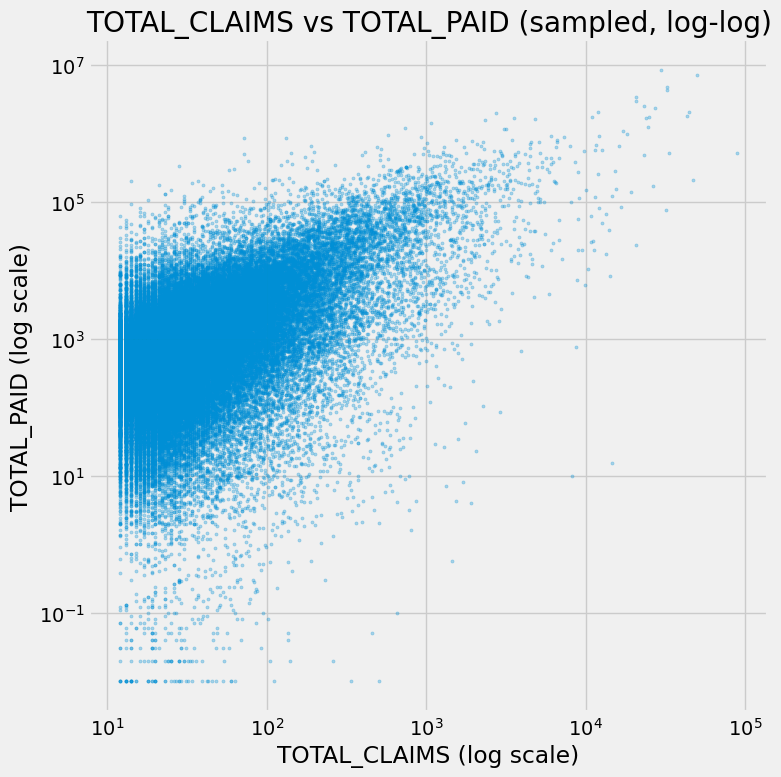

In [15]:
# 5. Relationship between TOTAL_CLAIMS and TOTAL_PAID (scatter, log-log)
# We sample rows to keep the plot manageable.
# Filter out non-positive values before log scales
mask = (claims_paid_df["TOTAL_CLAIMS"] > 0) & (claims_paid_df["TOTAL_PAID"] > 0)
plot_df = claims_paid_df[mask]

plt.figure(figsize=(8, 8))
plt.scatter(plot_df["TOTAL_CLAIMS"], plot_df["TOTAL_PAID"], s=5, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("TOTAL_CLAIMS (log scale)")
plt.ylabel("TOTAL_PAID (log scale)")
plt.title("TOTAL_CLAIMS vs TOTAL_PAID (sampled, log-log)")
plt.tight_layout()
plt.show()

In [19]:
claims_paid_df.corr()

,TOTAL_CLAIMS,TOTAL_PAID
TOTAL_CLAIMS,1.000000,0.594813
TOTAL_PAID,0.594813,1.000000


In [18]:
benef_claims_df.corr()

,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS
TOTAL_UNIQUE_BENEFICIARIES,1.000000,0.694301
TOTAL_CLAIMS,0.694301,1.000000


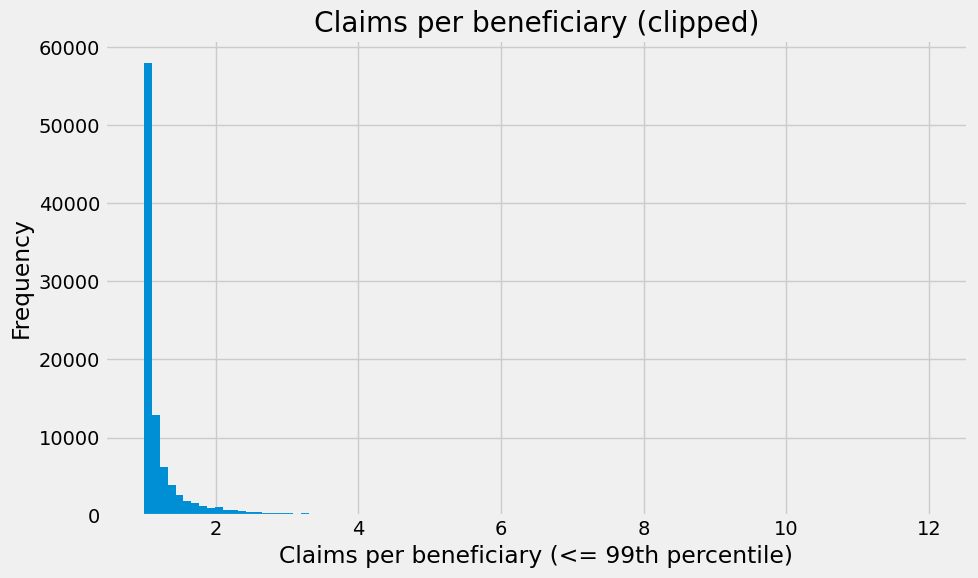

In [25]:
# Optional: clipped version if very skewed
upper_ratio = claims_per_benef.quantile(0.99)
plt.figure(figsize=(10, 6))
plt.hist(claims_per_benef[claims_per_benef <= upper_ratio], bins=100)
plt.xlabel("Claims per beneficiary (<= 99th percentile)")
plt.ylabel("Frequency")
plt.title("Claims per beneficiary (clipped)")
plt.tight_layout()
plt.show()

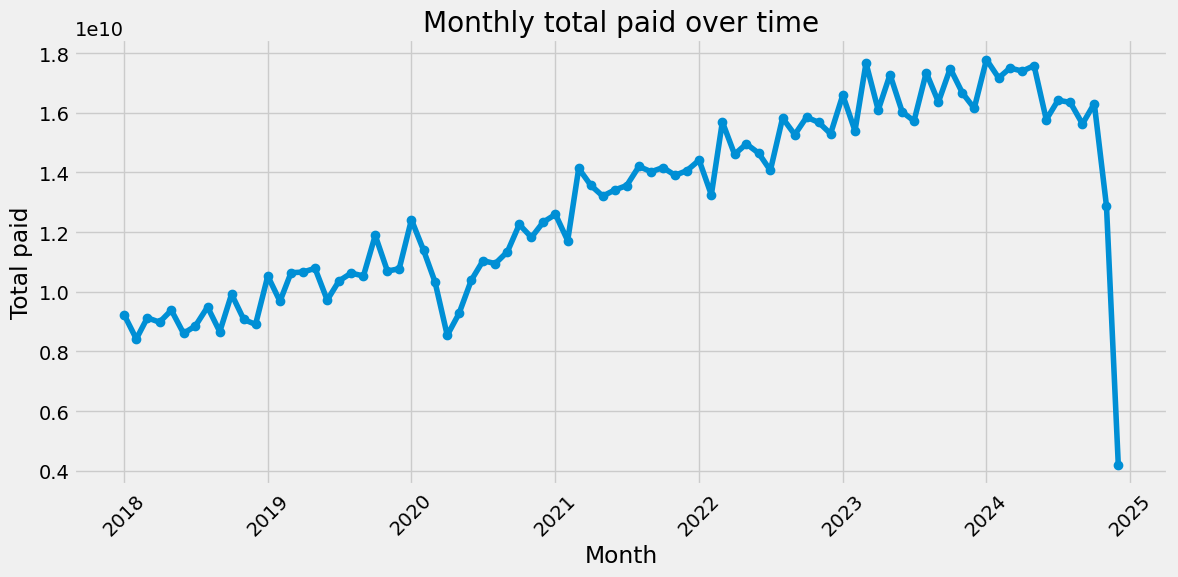

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_paid_df["CLAIM_FROM_MONTH"],
    monthly_paid_df["total_paid"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Total paid")
plt.title("Monthly total paid over time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

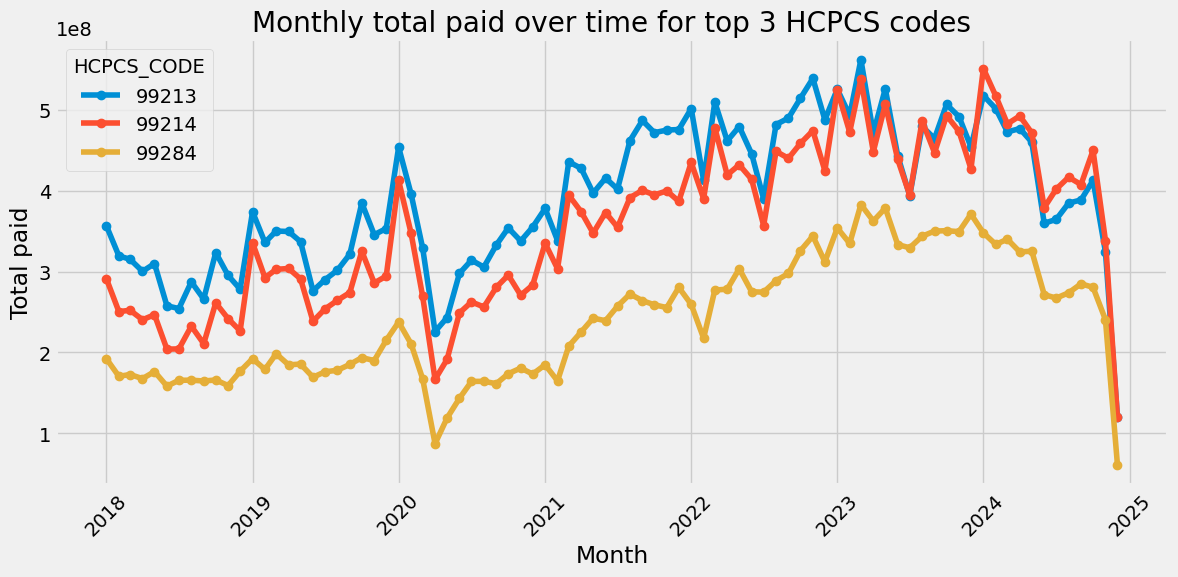

In [29]:

# Parse month as datetime and sort
monthly_code_paid_df["CLAIM_FROM_MONTH"] = pd.to_datetime(monthly_code_paid_df["CLAIM_FROM_MONTH"])
monthly_code_paid_df = monthly_code_paid_df.sort_values(["HCPCS_CODE", "CLAIM_FROM_MONTH"])
plt.figure(figsize=(12, 6))

for code in top3_codes:
    sub = monthly_code_paid_df[monthly_code_paid_df["HCPCS_CODE"] == code]
    plt.plot(
        sub["CLAIM_FROM_MONTH"],
        sub["total_paid"],   # or sub["total_claims"] if you changed the SQL
        marker="o",
        label=str(code)
    )

plt.xlabel("Month")
plt.ylabel("Total paid")
plt.title("Monthly total paid over time for top 3 HCPCS codes")
plt.xticks(rotation=45)
plt.legend(title="HCPCS_CODE")
plt.tight_layout()
plt.show()

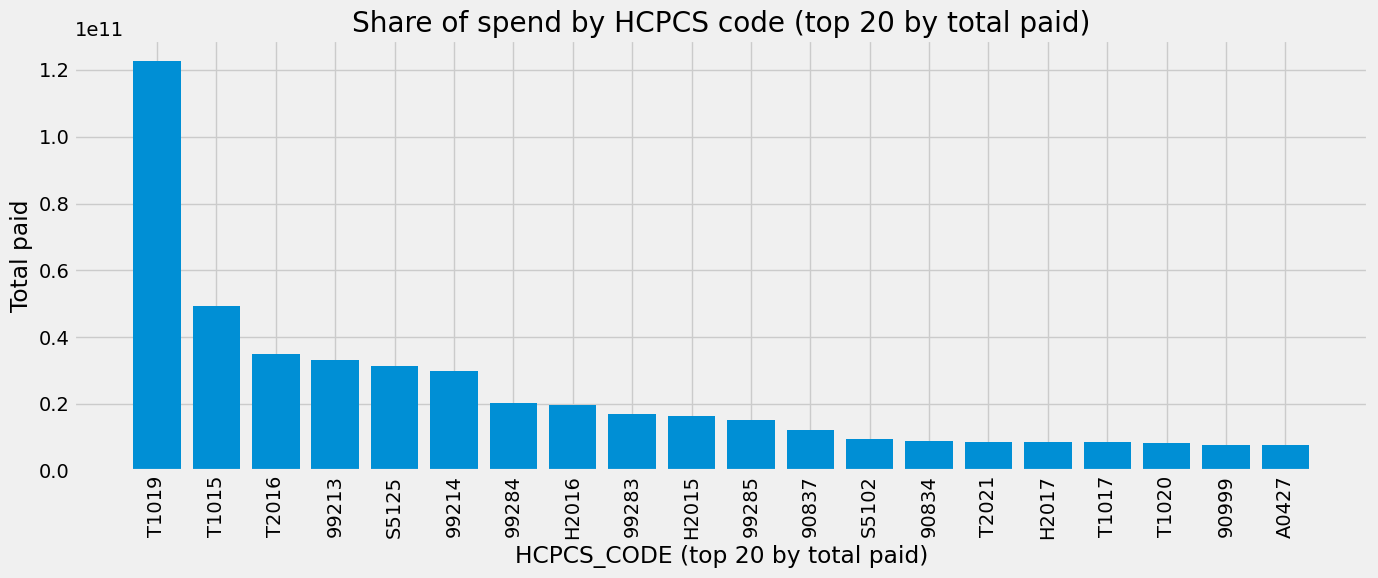

In [31]:
plt.figure(figsize=(14, 6))
plt.bar(hcpcs_spend_df["HCPCS_CODE"].astype(str), hcpcs_spend_df["total_paid"])
plt.xticks(rotation=90)
plt.xlabel("HCPCS_CODE (top 20 by total paid)")
plt.ylabel("Total paid")
plt.title("Share of spend by HCPCS code (top 20 by total paid)")
plt.tight_layout()
plt.show()

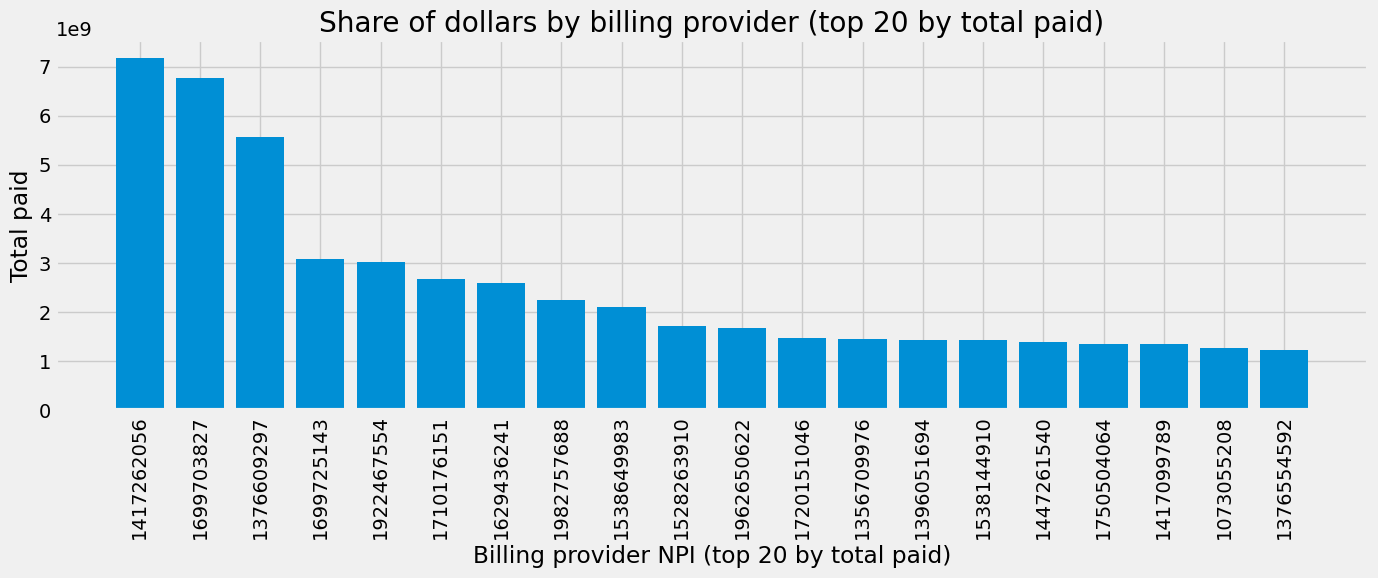

In [33]:
plt.figure(figsize=(14, 6))
plt.bar(
    provider_spend_df["BILLING_PROVIDER_NPI_NUM"].astype(str),
    provider_spend_df["total_paid"]
)
plt.xticks(rotation=90)
plt.xlabel("Billing provider NPI (top 20 by total paid)")
plt.ylabel("Total paid")
plt.title("Share of dollars by billing provider (top 20 by total paid)")
plt.tight_layout()
plt.show()

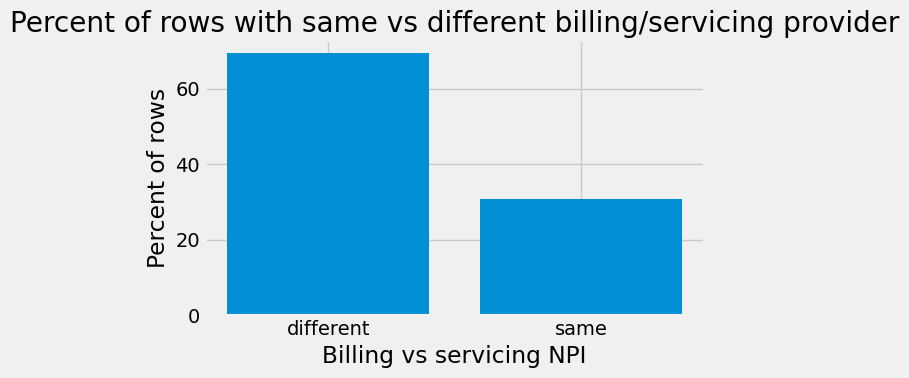

In [35]:
plt.figure(figsize=(6, 4))
plt.bar(
    billing_serving_match_df["same_vs_different"],
    billing_serving_match_df["percent"]
)
plt.ylabel("Percent of rows")
plt.xlabel("Billing vs servicing NPI")
plt.title("Percent of rows with same vs different billing/servicing provider")
plt.tight_layout()
plt.show()